### Para analizar hits de blast_reduced_THM10.mat a traves de los .csv

In [1]:
import pandas as pd
import glob

def promedios_hits_especificos():
    """
    Calcula promedios específicos para archivos de hits de BLAST/HMMER
    """
    archivos = glob.glob('*Hits*.csv') + glob.glob('*hits*.csv')
    
    if not archivos:
        print("No se encontraron archivos con 'Hits'")
        return
    
    resultados = []
    
    for archivo in archivos:
        try:
            # Leer CSV (ajusta sep si es necesario)
            df = pd.read_csv(archivo, sep=',')  # o delim_whitespace=True si está separado por espacios
            
            # Calcular promedios
            stats = {
                'Archivo': archivo,
                'Total_Hits': len(df),
                'Avg_Evalue': df['evalue'].mean(),
                'Avg_Identity': df['identity'].mean(),
                'Avg_Bitscore': df['bitscore'].mean(),
                'Avg_PPos': df['ppos'].mean(),
                'Min_Evalue': df['evalue'].min(),
                'Max_Identity': df['identity'].max()
            }
            resultados.append(stats)
            
        except KeyError as e:
            print(f"Error: Columna no encontrada en {archivo}: {e}")
        except Exception as e:
            print(f"Error procesando {archivo}: {e}")
    
    # Crear DataFrame de resultados
    df_resultados = pd.DataFrame(resultados)
    
    # Calcular promedios globales
    print("\nPROMEDIOS GLOBALES:")
    print("==================")
    for col in ['Avg_Evalue', 'Avg_Identity', 'Avg_Bitscore', 'Avg_PPos']:
        if col in df_resultados.columns:
            promedio = df_resultados[col].mean()
            print(f"{col}: {promedio:.4f}")
    
    return df_resultados

# Ejecutar
resultados = promedios_hits_especificos()
if resultados is not None:
    print("\nDetalles por archivo:")
    print(resultados.to_string(index=False))



PROMEDIOS GLOBALES:
Avg_Evalue: 0.0000
Avg_Identity: 44.1029
Avg_Bitscore: 310.1424
Avg_PPos: 60.7021

Detalles por archivo:
                                     Archivo  Total_Hits   Avg_Evalue  Avg_Identity  Avg_Bitscore  Avg_PPos  Min_Evalue  Max_Identity
 Hits_THM10_vs_iANid1221_protein_reduced.csv        2755 4.575506e-07     41.351561    220.829183 57.992802         0.0        97.794
 Hits_THM10_vs_iANig1029_protein_reduced.csv        2059 2.539396e-07     48.236406    381.268626 63.957717         0.0        92.744
   Hits_THM10_vs_iAP1008_protein_reduced.csv        2113 2.801941e-07     47.980415    369.653573 63.707454         0.0        92.744
   Hits_THM10_vs_iDC1003_protein_reduced.csv        1783 2.643730e-07     42.198176    278.397869 59.461671         0.0        82.628
  Hits_THM10_vs_iIsor850_protein_reduced.csv        1688 2.909030e-07     42.444084    268.251836 59.566428         0.0        85.535
   Hits_THM10_vs_iPrub22_protein_reduced.csv        5963 2.919433e-07 

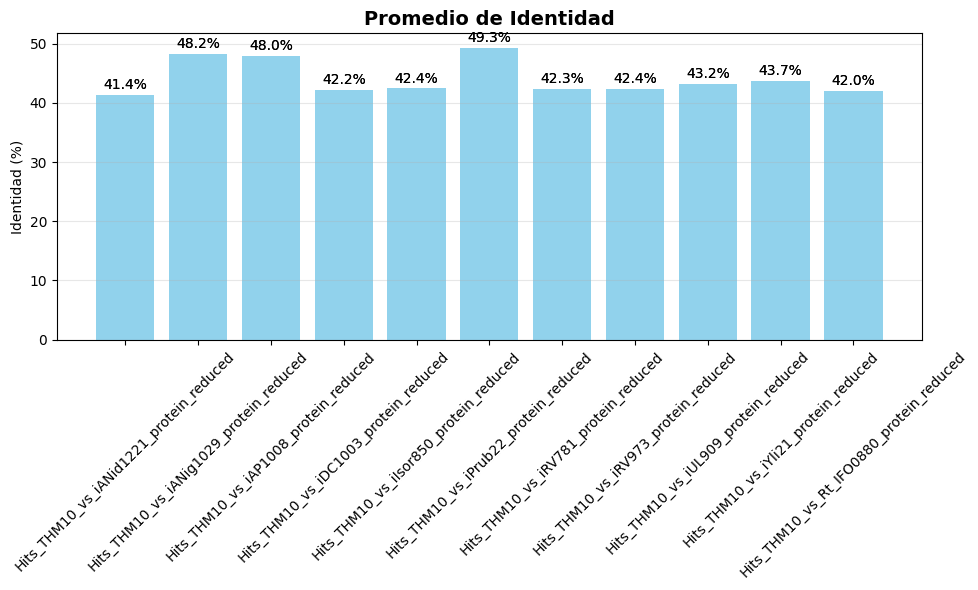

In [2]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if resultados is not None:
    # Crear columna 'Nombre_Corto' si no existe
    if 'Nombre_Corto' not in resultados.columns:
        resultados['Nombre_Corto'] = resultados['Archivo'].str.replace('.csv', '', regex=False)
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(resultados['Nombre_Corto'], resultados['Avg_Identity'], color='skyblue', alpha=0.7)
    plt.title('Promedio de Identidad', fontsize=14, fontweight='bold')
    plt.ylabel('Identidad (%)')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    
    # Añadir valores en las barras
    for bar, v in zip(bars, resultados['Avg_Identity']):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                f'{v:.1f}%', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()

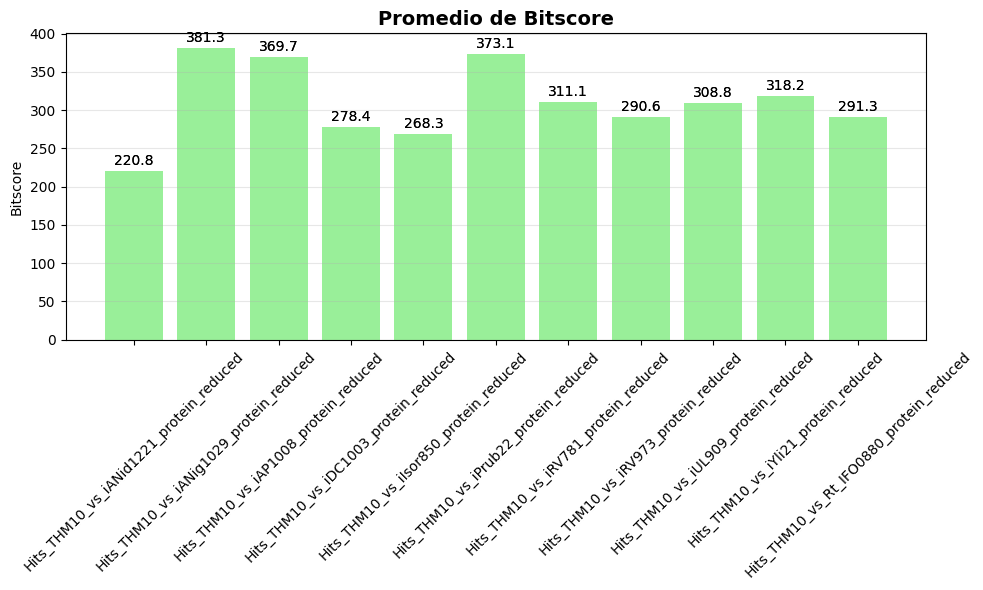

In [3]:
if resultados is not None:
    plt.figure(figsize=(10, 6))
    bars = plt.bar(resultados['Nombre_Corto'], resultados['Avg_Bitscore'], color='lightgreen', alpha=0.7)
    plt.title('Promedio de Bitscore', fontsize=14, fontweight='bold')
    plt.ylabel('Bitscore')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    
    # Añadir valores en las barras
    for bar, v in zip(bars, resultados['Avg_Bitscore']):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(resultados['Avg_Bitscore'])*0.01, 
                f'{v:.1f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()

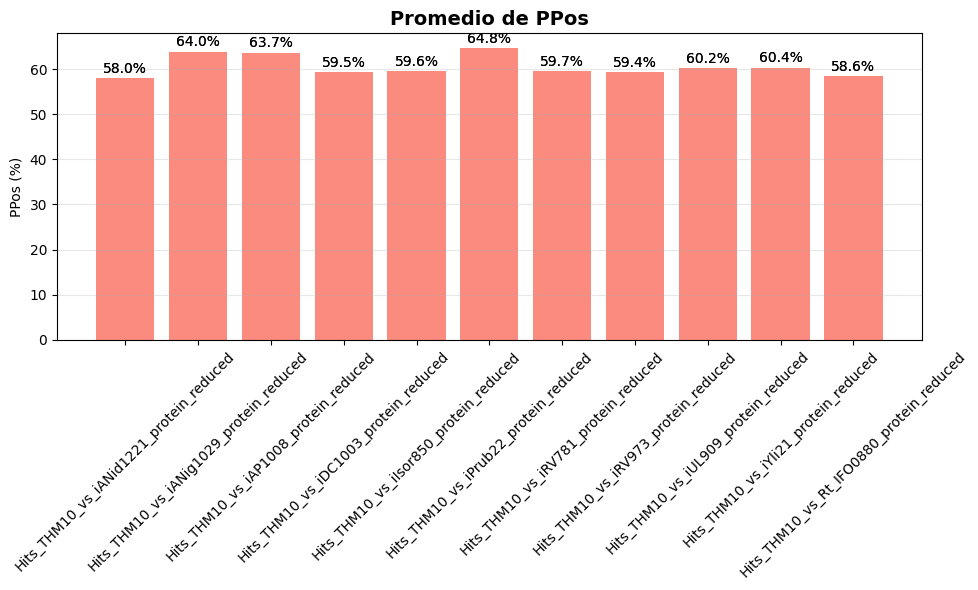

In [4]:
if resultados is not None:
    plt.figure(figsize=(10, 6))
    bars = plt.bar(resultados['Nombre_Corto'], resultados['Avg_PPos'], color='salmon', alpha=0.7)
    plt.title('Promedio de PPos', fontsize=14, fontweight='bold')
    plt.ylabel('PPos (%)')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    
    # Añadir valores en las barras
    for bar, v in zip(bars, resultados['Avg_PPos']):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                f'{v:.1f}%', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()

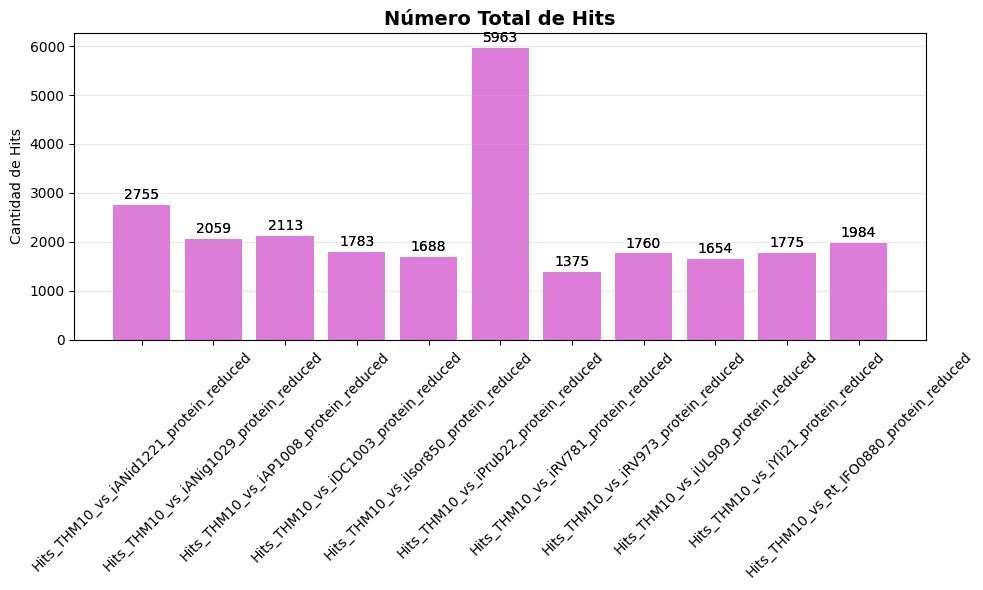

In [6]:
if resultados is not None:
    plt.figure(figsize=(10, 6))
    bars = plt.bar(resultados['Nombre_Corto'], resultados['Total_Hits'], color='orchid', alpha=0.7)
    plt.title('Número Total de Hits', fontsize=14, fontweight='bold')
    plt.ylabel('Cantidad de Hits')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    
    # Añadir valores en las barras
    for bar, v in zip(bars, resultados['Total_Hits']):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(resultados['Total_Hits'])*0.01, 
                f'{v}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()

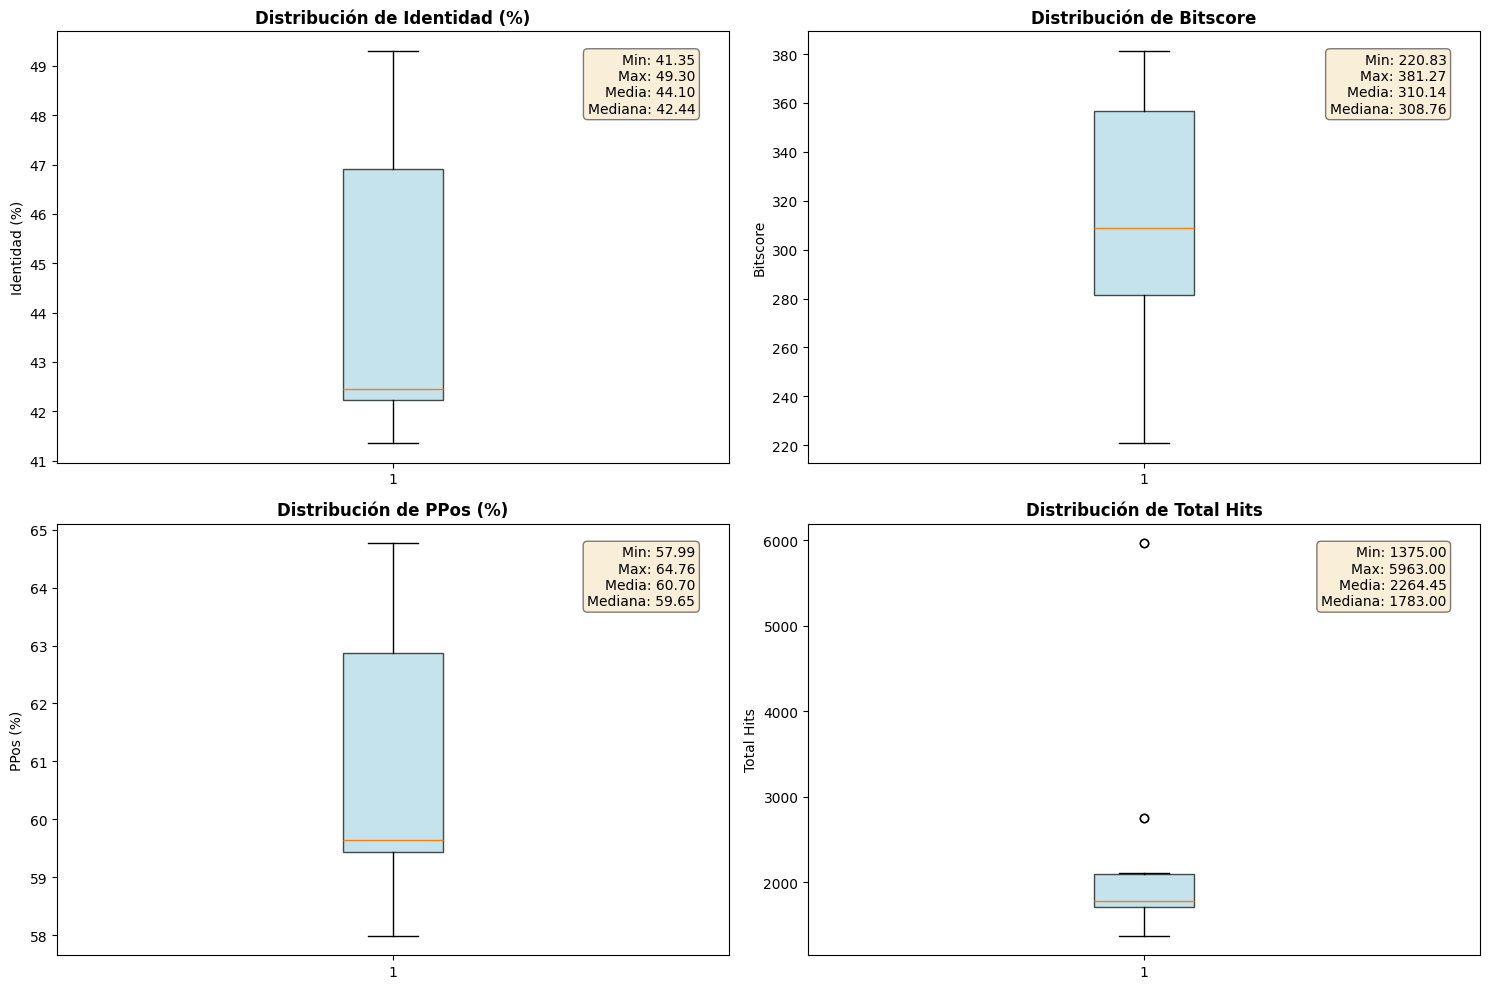

In [7]:
if resultados is not None:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.ravel()
    
    metricas = ['Avg_Identity', 'Avg_Bitscore', 'Avg_PPos', 'Total_Hits']
    nombres = ['Identidad (%)', 'Bitscore', 'PPos (%)', 'Total Hits']
    
    for i, (metrica, nombre) in enumerate(zip(metricas, nombres)):
        data = resultados[metrica]
        
        # Boxplot
        axes[i].boxplot(data, vert=True, patch_artist=True, 
                       boxprops=dict(facecolor='lightblue', alpha=0.7))
        axes[i].set_title(f'Distribución de {nombre}', fontweight='bold')
        axes[i].set_ylabel(nombre)
        
        # Añadir valores estadísticos
        stats_text = f"""Min: {data.min():.2f}\nMax: {data.max():.2f}\nMedia: {data.mean():.2f}\nMediana: {data.median():.2f}"""
        
        axes[i].text(0.95, 0.95, stats_text, transform=axes[i].transAxes, 
                    verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                    fontsize=10)
    
    plt.tight_layout()
    plt.show()
